In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/titanic-dataset")

print("Path to dataset files:", path)

100%|██████████| 22.0k/22.0k [00:00<00:00, 24.5MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/yasserh/titanic-dataset/versions/1


In [ ]:

!cp -r /root/.cache/kagglehub/datasets/yasserh/titanic-dataset/versions/1 /.content/

In [ ]:
import pandas as pd
df =pd.read_csv('/.content/Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
len(df["Cabin"].unique())

148

In [ ]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.shape

(891, 12)

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df.duplicated().sum()

0

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
X = df.drop(['Survived','PassengerId','Name','Ticket'] ,axis=1)
y = df['Survived']

In [ ]:
X['Sex'].value_counts()

,count
Sex,
male,577
female,314


In [ ]:
X['Sex'] = X['Sex'].map({'male': 1, 'female': 0})
X['Sex'].dtype

dtype('int64')

In [ ]:
X['Embarked']=X['Embarked'].fillna(X['Embarked'].mode()[0])

In [ ]:
X['Embarked'].value_counts()

,count
Embarked,
S,646
C,168
Q,77


In [ ]:
X['Embarked'] = X['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
X['Embarked'].dtype

dtype('int64')

In [ ]:
X['Cabin'] = X['Cabin'].apply(lambda x: 0 if pd.isnull(x) else 1)

In [ ]:
X['Cabin'].value_counts()

,count
Cabin,
0,687
1,204


In [ ]:
df = pd.concat([X, y] ,axis=1).dropna()
X = df.drop(['Survived'] ,axis=1)
y = df['Survived']

In [ ]:
X.isnull().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Cabin,0
Embarked,0


In [ ]:
import matplotlib.pyplot as plt

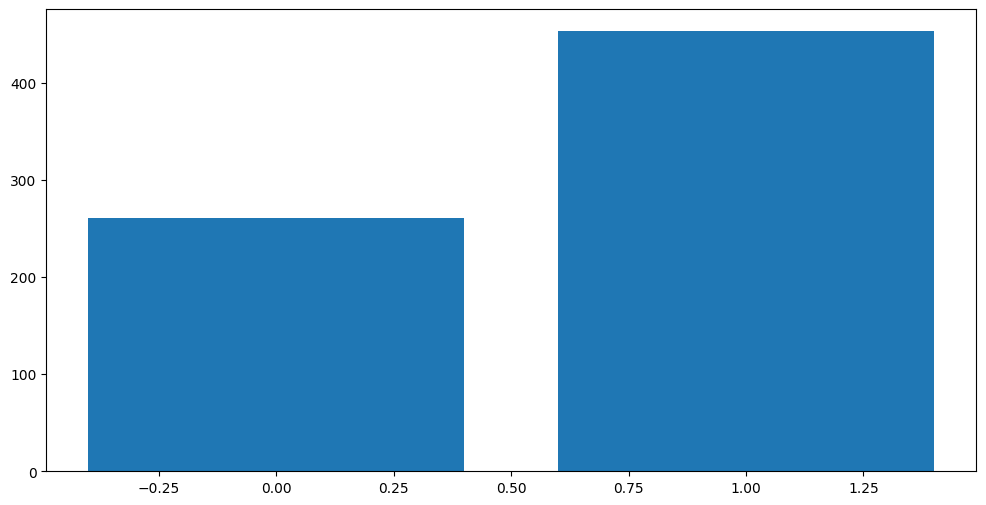

In [ ]:
plt.figure(figsize=(12, 6))
plt.bar(X['Sex'].value_counts().index, X['Sex'].value_counts())
plt.show()

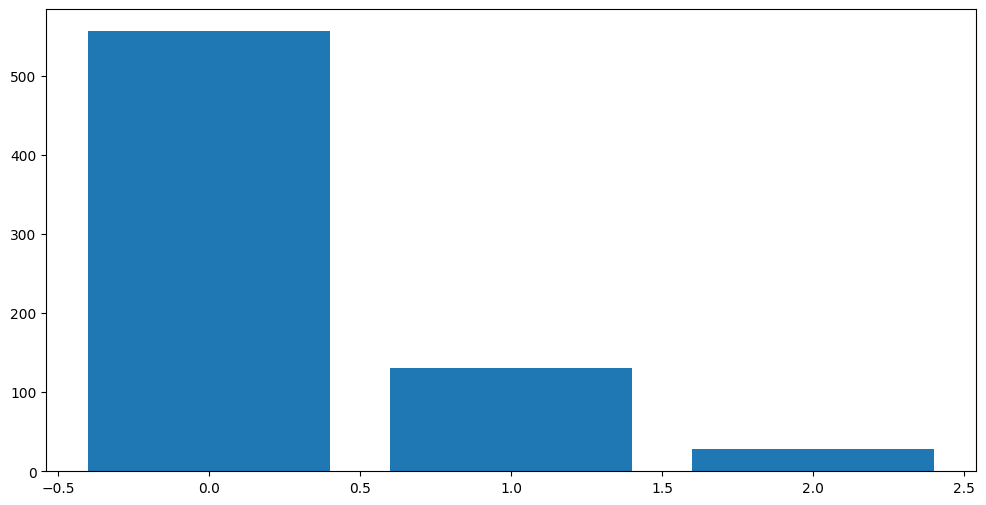

In [ ]:
plt.figure(figsize=(12, 6))
plt.bar(X['Embarked'].value_counts().index, X['Embarked'].value_counts())
plt.show()

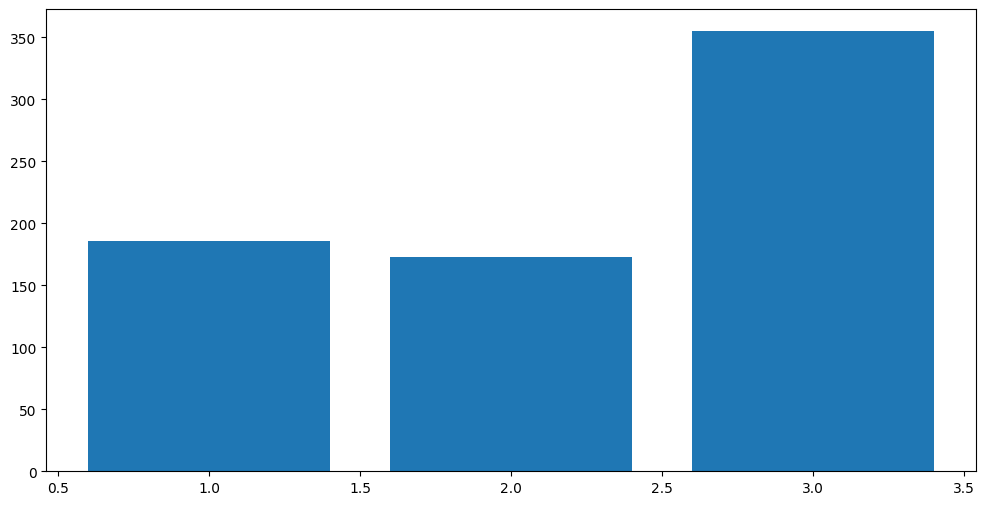

In [ ]:
plt.figure(figsize=(12, 6))
plt.bar(X['Pclass'].value_counts().index, X['Pclass'].value_counts())
plt.show()

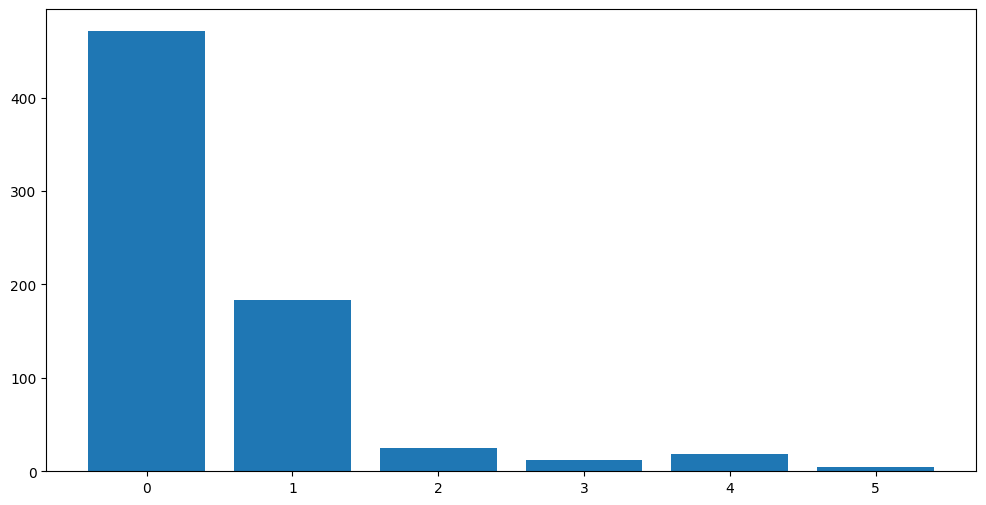

In [ ]:
plt.figure(figsize=(12, 6))
plt.bar(X['SibSp'].value_counts().index, X['SibSp'].value_counts())
plt.show()

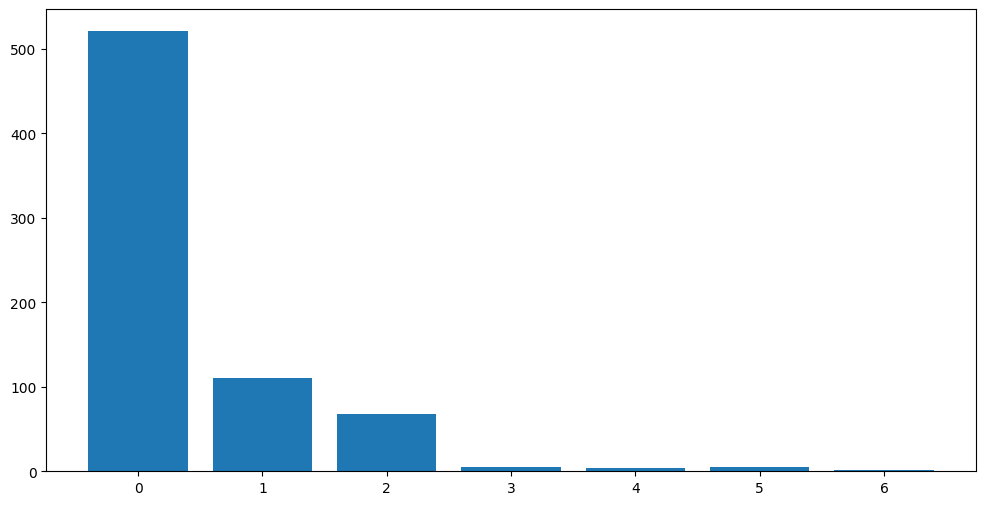

In [ ]:
plt.figure(figsize=(12, 6))
plt.bar(X['Parch'].value_counts().index, X['Parch'].value_counts())
plt.show()

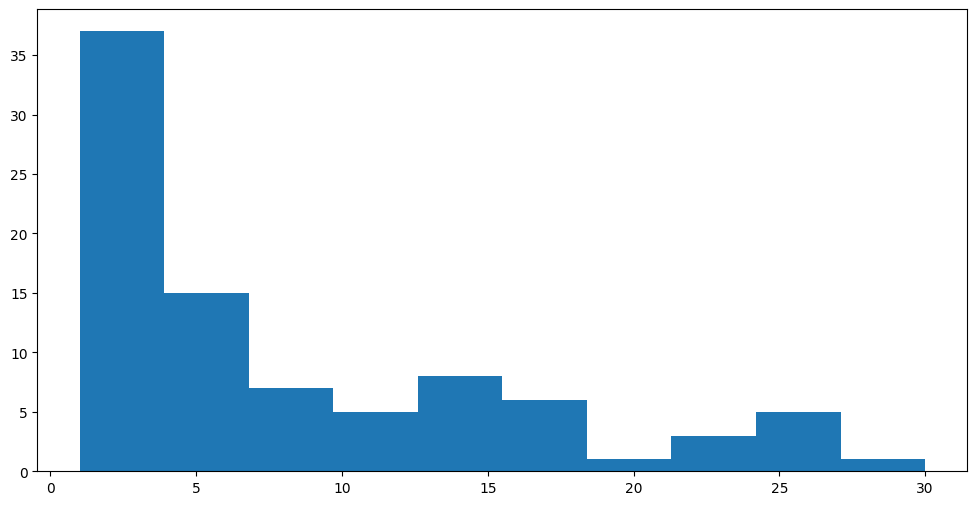

In [ ]:
plt.figure(figsize=(12, 6))
plt.hist(X['Age'].value_counts())
plt.show()

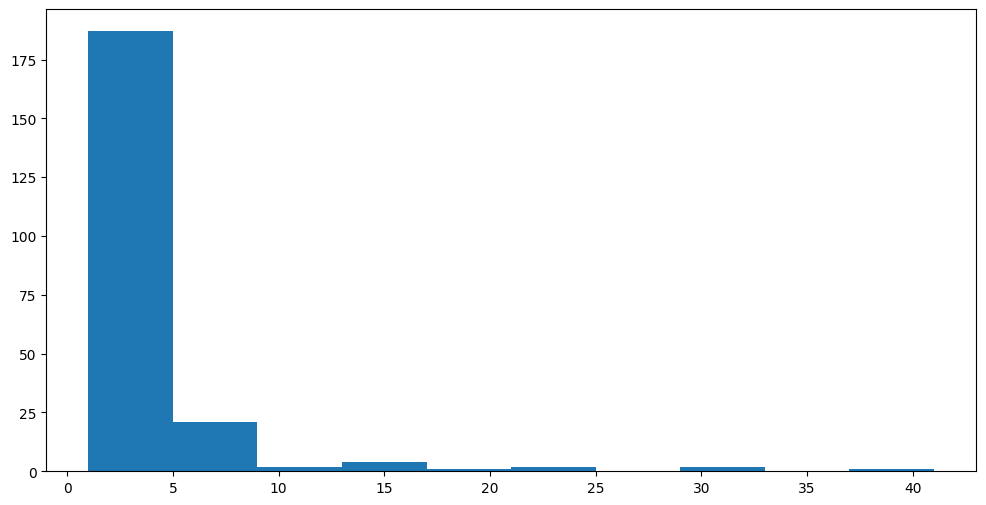

In [ ]:
plt.figure(figsize=(12, 6))
plt.hist(X['Fare'].value_counts())
plt.show()

<Axes: xlabel='Sex', ylabel='Survived'>

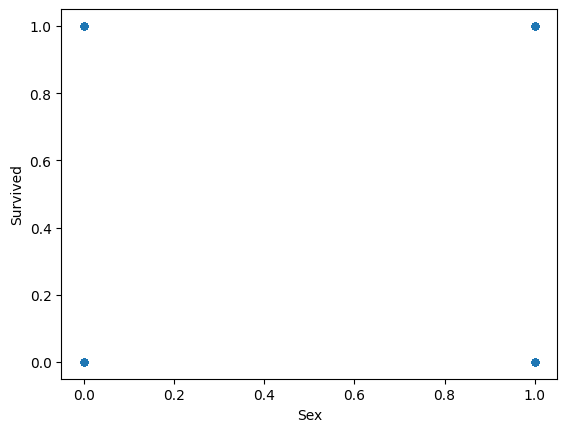

In [ ]:
df.plot.scatter(x='Sex', y='Survived')

In [ ]:
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,3.0,1.0,22.0,1.0,0.0,0.014151,0.0,0.0
1,1.0,0.0,38.0,1.0,0.0,0.139136,1.0,1.0
2,3.0,0.0,26.0,0.0,0.0,0.015469,0.0,0.0
3,1.0,0.0,35.0,1.0,0.0,0.103644,1.0,0.0
4,3.0,1.0,35.0,0.0,0.0,0.015713,0.0,0.0


In [ ]:
columns_to_scale = ['Fare']

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
scaler = MinMaxScaler()
X[columns_to_scale] = scaler.fit_transform(X[columns_to_scale])

In [ ]:
correlation = pd.concat([X, y], axis=1).corr()
correlation

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Survived
Pclass,1.000000,0.155460,-0.369226,0.067247,0.025683,-0.554182,-0.739512,-0.106056,-0.359653
Sex,0.155460,1.000000,0.093254,-0.103950,-0.246972,-0.184994,-0.148511,-0.095006,-0.538826
Age,-0.369226,0.093254,1.000000,-0.308247,-0.189119,0.096067,0.249732,0.010171,-0.077221
SibSp,0.067247,-0.103950,-0.308247,1.000000,0.383820,0.138329,-0.033826,0.004793,-0.017358
Parch,0.025683,-0.246972,-0.189119,0.383820,1.000000,0.205119,0.026977,-0.013361,0.093317
Fare,-0.554182,-0.184994,0.096067,0.138329,0.205119,1.000000,0.492069,0.175410,0.268189
Cabin,-0.739512,-0.148511,0.249732,-0.033826,0.026977,0.492069,1.000000,0.127746,0.324530
Embarked,-0.106056,-0.095006,0.010171,0.004793,-0.013361,0.175410,0.127746,1.000000,0.106556
Survived,-0.359653,-0.538826,-0.077221,-0.017358,0.093317,0.268189,0.324530,0.106556,1.000000


In [ ]:
import seaborn as sns

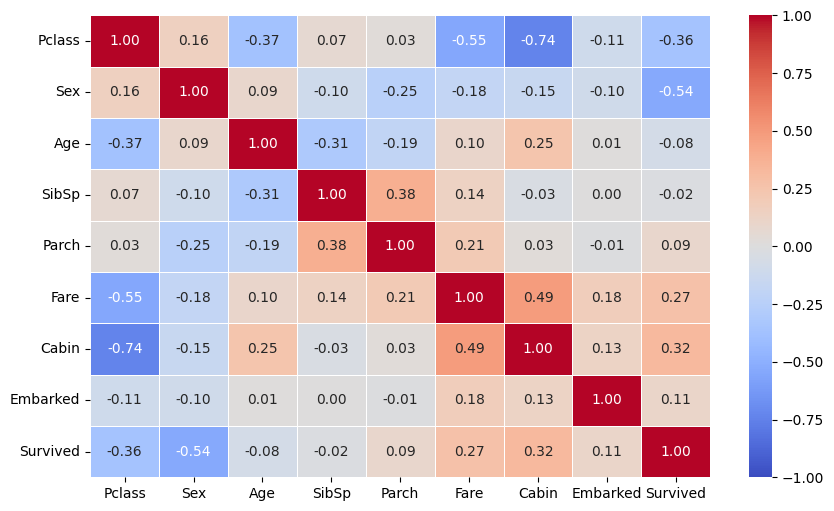

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(correlation, vmin=-1, vmax=1, annot=True, cmap='coolwarm', fmt='.2f', cbar=True, linewidths=0.5)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((571, 8), (143, 8), (571,), (143,))

In [ ]:
y_train

,Survived
328,1
73,0
253,0
719,0
666,0
...,...
92,0
134,0
337,1
548,0


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import cross_validate
from sklearn.metrics import log_loss, accuracy_score

In [ ]:
results = {}

In [ ]:
models =[RandomForestClassifier,GradientBoostingClassifier,KNeighborsClassifier, DecisionTreeClassifier,LogisticRegression,SVC]

In [1]:
# Ensure the models variable is defined
models = [RandomForestClassifier, GradientBoostingClassifier, KNeighborsClassifier, DecisionTreeClassifier, LogisticRegression, SVC]

for model_name in models:
    model = model_name()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    if model_name == SVC:
        y_pred = model.predict(X_test)
        rmse = log_loss(y_test, y_pred)
    else:
        y_pred_proba = model.predict_proba(X_test)
        rmse = log_loss(y_test, y_pred_proba)
    acc = accuracy_score(y_test, y_pred)
    results[model_name.__name__] = {'loss': rmse, 'acc': acc}

NameError: name 'models' is not defined

In [ ]:
pd_results = pd.DataFrame(results).T
pd_results

,loss,acc
RandomForestClassifier,0.750581,0.769231
GradientBoostingClassifier,0.457760,0.797203
KNeighborsClassifier,1.455384,0.748252
DecisionTreeClassifier,9.330827,0.734266
LogisticRegression,0.511228,0.755245
SVC,13.610890,0.622378


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
grid1 ={
    'learning_rate': [0.05, 0.06, 0.04, 0.03, 0.02, 0.01],
}
grid_search = RandomizedSearchCV(estimator=GradientBoostingClassifier(random_state=42), param_distributions=grid1, cv=5, scoring="accuracy")
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
print(grid_search.best_score_)
print(best_params)

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


0.8336384439359268
{'learning_rate': 0.05}


In [ ]:
model = GradientBoostingClassifier(random_state=42,learning_rate=0.05)
model.fit(X_train,y_train)

GradientBoostingClassifier(learning_rate=0.05, random_state=42)

In [ ]:
from sklearn.metrics import confusion_matrix,classification_report
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_train)
print(classification_report(y_train, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.85      0.84       337
           1       0.78      0.75      0.77       234

    accuracy                           0.81       571
   macro avg       0.81      0.80      0.80       571
weighted avg       0.81      0.81      0.81       571



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
import pickle

In [ ]:
with open('model.pkl', 'wb') as f:
  pickle.dump(
      {
          'scaler': scaler,
          'model': model
      }
      , f)

In [ ]:
with open('model.pkl', 'rb') as f:
  model = pickle.load(f)